# Phishing Detection ג€” Reproduction Study

Based on: Shahrivari et al. (2020), *Phishing Detection Using Machine Learning Techniques*  
Original repo: https://github.com/fafal-abnir/phishing_detection  
Dataset: UCI Phishing Websites (pre-extracted URL features)

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_PATH = "data/dataset.csv"
sns.set_theme(style="whitegrid", palette="muted")

## 1. Data Loading

In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)
df.head()

,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
index,,,,,,,,,,,,,,,,,,,,,
1,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
2,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
3,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
4,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
5,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [3]:
print("Shape:", df.shape)
print("\nDtypes:", df.dtypes.value_counts().to_dict())
print("\nMissing values (total):", df.isna().sum().sum())

Shape: (11055, 31)

Dtypes: {dtype('int64'): 31}

Missing values (total): 0


In [4]:
# Column and index inspection
print("Columns with naming issues (typos / duplicates in name):")
for col in df.columns:
    if col.count("_") > 2 or col.lower() != col.replace("having_IPhaving_IP", ""):
        pass
suspicious = [c for c in df.columns if "having_IPhaving" in c or "URLURL" in c or "Shortining" in c or "registeration" in c or "popUpWidnow" in c]
print(suspicious)

print("\nIndex: min =", df.index.min(), ", max =", df.index.max(), ", unique =", df.index.is_unique)
print("Index appears to be a row ID from export, not a time index.")

Columns with naming issues (typos / duplicates in name):
['having_IPhaving_IP_Address', 'URLURL_Length', 'Shortining_Service', 'Domain_registeration_length', 'popUpWidnow']

Index: min = 1 , max = 11055 , unique = True
Index appears to be a row ID from export, not a time index.


In [5]:
# Target: -1 = phishing, 1 = legitimate (per paper and UCI dataset spec)
LABEL_MAP = {-1: "phishing", 1: "legitimate"}
class_counts = df["Result"].value_counts().sort_index()
class_counts.index = class_counts.index.map(LABEL_MAP)
print(class_counts)
print(f"\nPhishing rate: {class_counts['phishing'] / len(df):.1%}")

Result
phishing      4898
legitimate    6157
Name: count, dtype: int64

Phishing rate: 44.3%


In [6]:
# Single-value features, irrelevant columns, duplicates
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
dup_cols = df.T[df.T.duplicated()].index.tolist()
print("Constant columns:", constant_cols or "none")
print("Duplicate feature columns:", dup_cols or "none")

feature_cols = [c for c in df.columns if c != "Result"]
print(f"\nFeature value sets are small integers (mostly -1, 0, 1) ג€” pre-encoded by dataset authors.")

Constant columns: none
Duplicate feature columns: none

Feature value sets are small integers (mostly -1, 0, 1) ג€” pre-encoded by dataset authors.


**Temporal analysis:** This dataset has no date/time column. Features are static URL/website attributes collected at an unknown point in time. Temporal EDA is not applicable; class balance reflects the sampling of the UCI corpus, not a time series.

## 2. Exploratory Data Analysis (EDA)

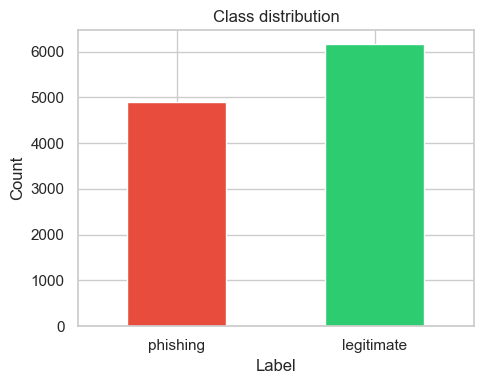

In [7]:
# Class imbalance ג€” real-world meaning
fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Class distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ~56% legitimate / 44% phishing ג€” mild imbalance; FN (missed phishing) is often
# more costly in security, so recall on the phishing class matters more than accuracy.

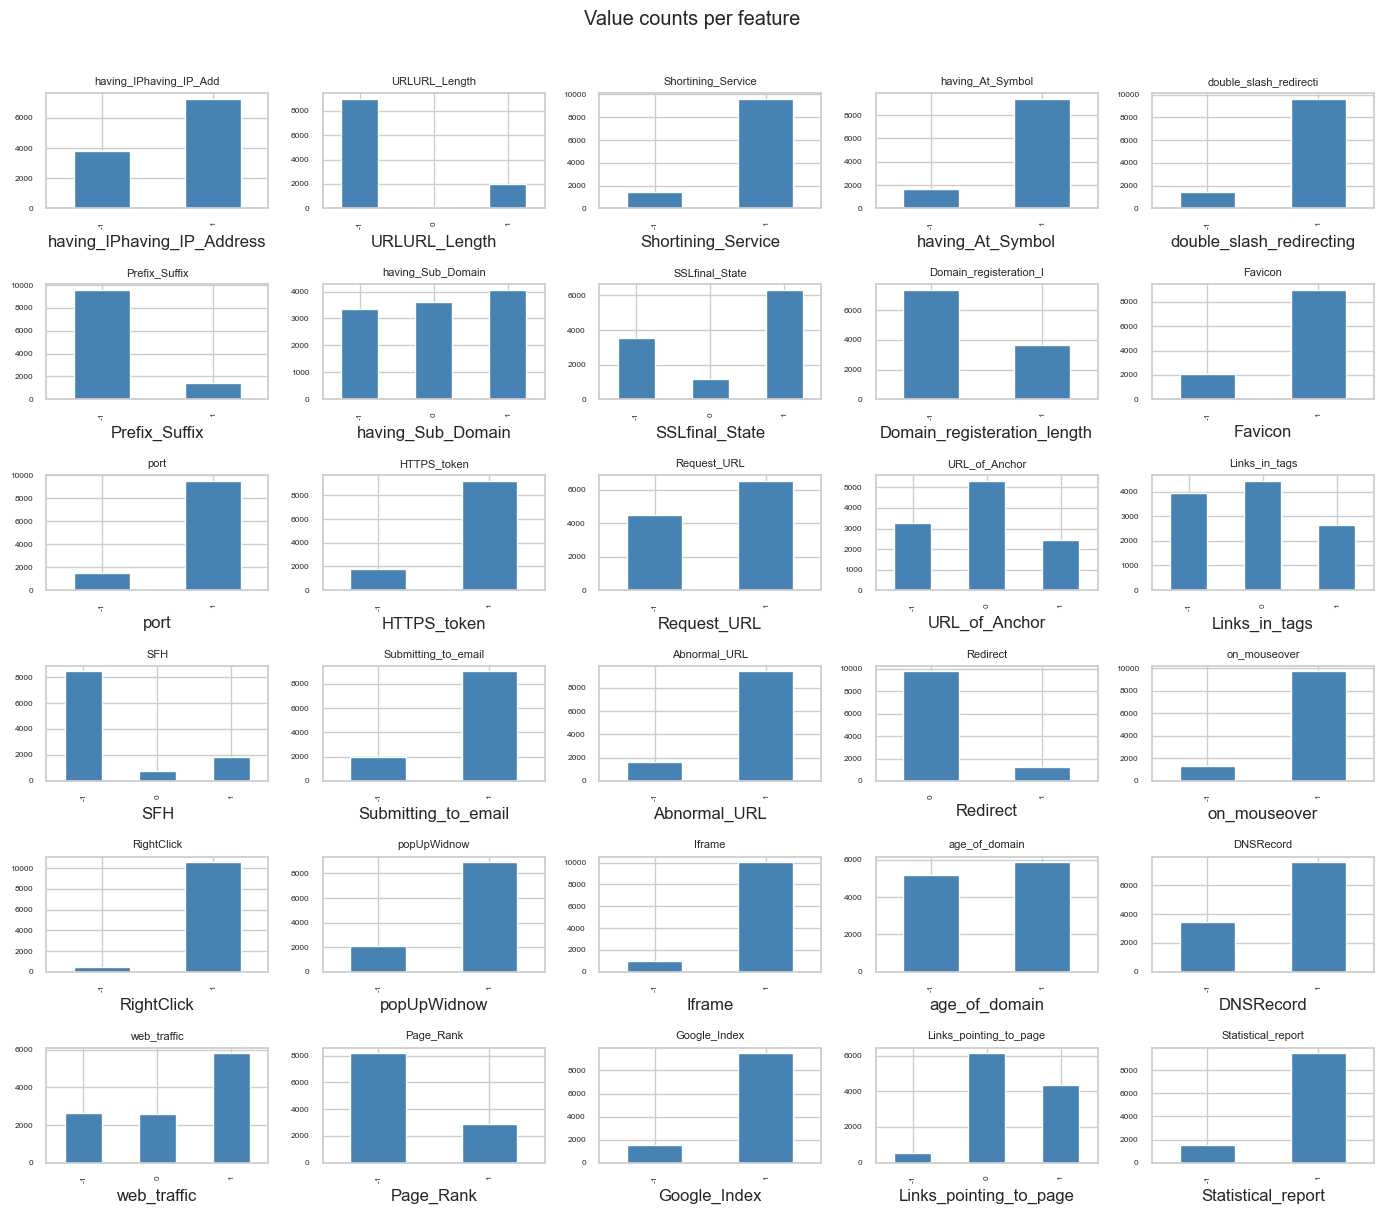

In [8]:
# Feature distributions (encoded as -1, 0, 1)
fig, axes = plt.subplots(6, 5, figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(feature_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(col[:22], fontsize=8)
    axes[i].tick_params(labelsize=6)
plt.suptitle("Value counts per feature", y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Correlation with target ג€” Spearman (monotonic, robust for ordinal {-1,0,1} features)
corr_with_target = df[feature_cols + ["Result"]].corr(method="spearman")["Result"].drop("Result").sort_values(key=abs, ascending=False)
print("Top features by |Spearman correlation| with Result:")
print(corr_with_target.head(10).round(3))

Top features by |Spearman correlation| with Result:
SSLfinal_State                 0.736
URL_of_Anchor                  0.701
web_traffic                    0.365
Prefix_Suffix                  0.349
having_Sub_Domain              0.305
Request_URL                    0.253
Links_in_tags                  0.251
Domain_registeration_length   -0.226
SFH                            0.219
Google_Index                   0.129
Name: Result, dtype: float64


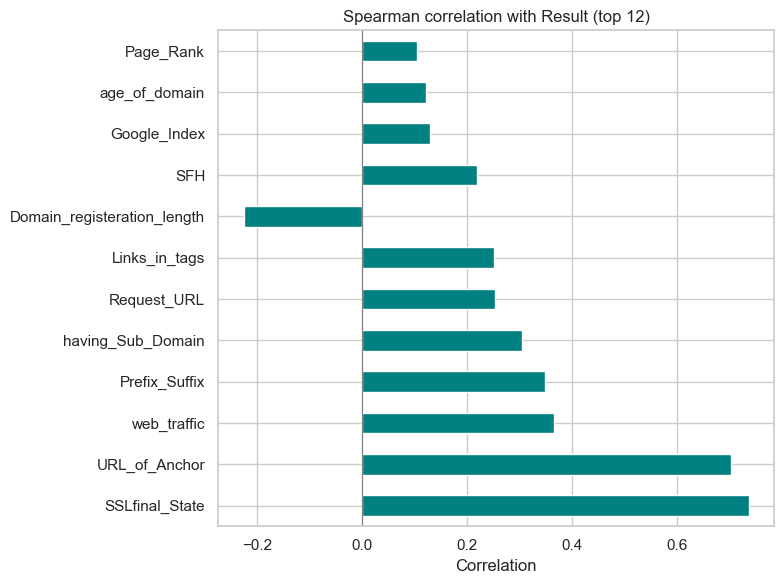

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.head(12).plot(kind="barh", ax=ax, color="teal")
ax.set_title("Spearman correlation with Result (top 12)")
ax.set_xlabel("Correlation")
ax.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

In [11]:
# Feature-feature correlation (Spearman) ג€” redundancy check
feature_corr = df[feature_cols].corr(method="spearman")
high_pairs = []
for i, a in enumerate(feature_cols):
    for b in feature_cols[i + 1:]:
        r = feature_corr.loc[a, b]
        if abs(r) >= 0.7:
            high_pairs.append((a, b, round(r, 3)))
print(f"Feature pairs with |Spearman r| >= 0.7: {len(high_pairs)}")
for pair in sorted(high_pairs, key=lambda x: -abs(x[2]))[:8]:
    print(pair)

Feature pairs with |Spearman r| >= 0.7: 12
('Favicon', 'popUpWidnow', 0.94)
('Shortining_Service', 'double_slash_redirecting', 0.843)
('Favicon', 'port', 0.804)
('port', 'Submitting_to_email', 0.799)
('double_slash_redirecting', 'HTTPS_token', 0.761)
('Shortining_Service', 'HTTPS_token', 0.758)
('port', 'popUpWidnow', 0.749)
('Shortining_Service', 'Abnormal_URL', 0.739)


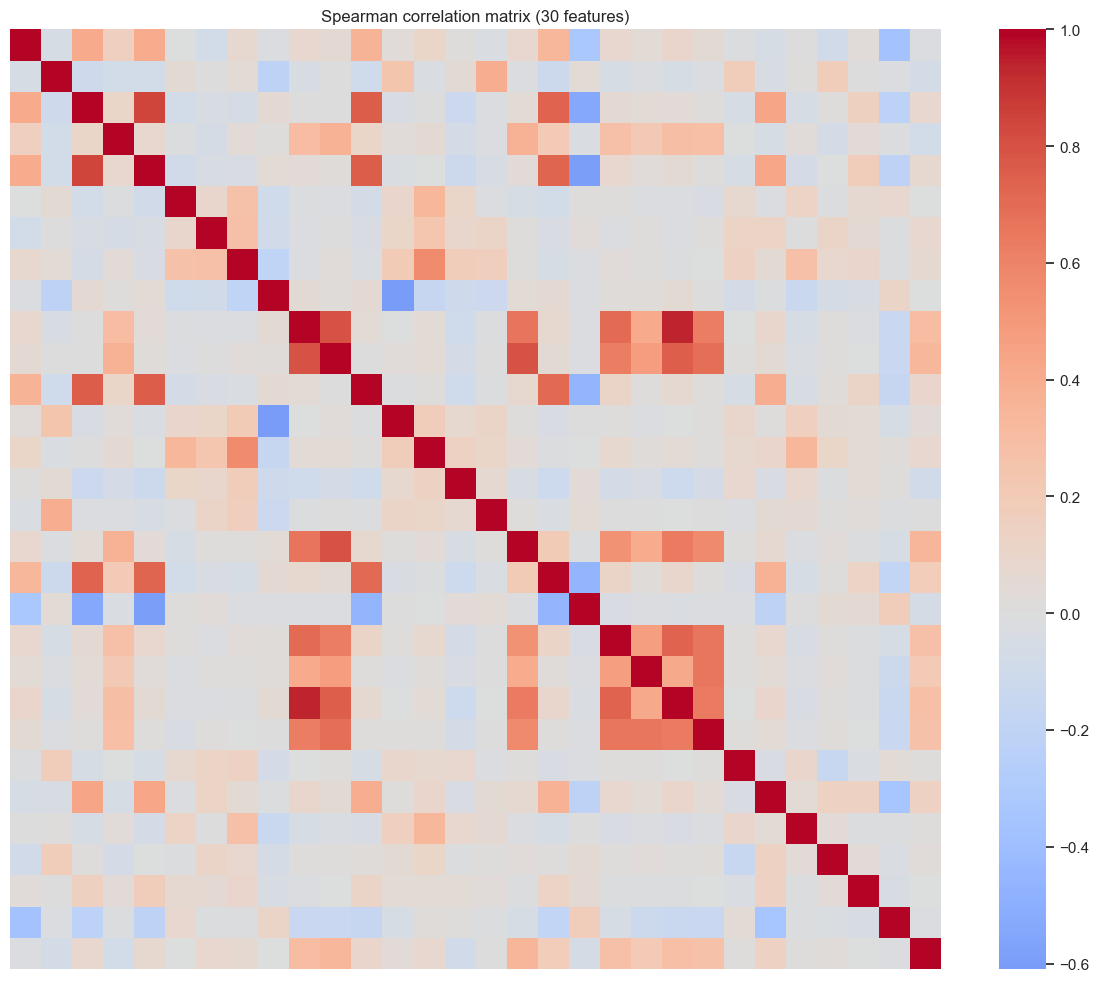

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(feature_corr, cmap="coolwarm", center=0, ax=ax, xticklabels=False, yticklabels=False)
ax.set_title("Spearman correlation matrix (30 features)")
plt.tight_layout()
plt.show()

In [13]:
# Group-by: mean feature value by class (crosstab-style view for top correlated features)
top_features = corr_with_target.head(6).index.tolist()
grouped = df.groupby("Result")[top_features].mean().T
grouped.columns = grouped.columns.map(LABEL_MAP)
grouped

Result,phishing,legitimate
SSLfinal_State,-0.479788,0.832223
URL_of_Anchor,-0.632095,0.365438
web_traffic,-0.033891,0.542797
Prefix_Suffix,-1.000000,-0.524119
having_Sub_Domain,-0.209473,0.281468
Request_URL,-0.092283,0.408803


**Correlation methodology:** We use **Spearman** because features are discrete/ordinal (-1, 0, 1), not necessarily linear. Pearson assumes linearity and normality; Kendall is alternative for small n per tie ג€” Spearman is a practical middle ground for monotonic relationships. Several URL-structure features (e.g. Prefix_Suffix, SSLfinal_State) correlate strongly with the label, which aligns with phishing intuition (suspicious URLs, invalid SSL).

## 3. Feature Engineering

**Run the code cells in sections 3-6 below.**


Features are already encoded in the UCI dataset (-1, 0, 1). No categorical encoding is needed.
Improvements over the authors' pipeline:
- **StandardScaler inside a Pipeline** (fitted per CV fold, avoids leakage from global scaling)
- **Fixed random_state** for shuffling and models
- **StratifiedKFold** to preserve class ratio in each fold

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

df_model = df.sample(frac=1, random_state=RANDOM_STATE)
X = df_model.drop("Result", axis=1)
y = df_model["Result"].values
y_bin = ((y + 1) // 2).astype(int)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

phishing_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label=-1),
    "recall": make_scorer(recall_score, pos_label=-1),
    "f1": make_scorer(f1_score, pos_label=-1),
    "mcc": "matthews_corrcoef",
}
phishing_scoring_bin = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label=0),
    "recall": make_scorer(recall_score, pos_label=0),
    "f1": make_scorer(f1_score, pos_label=0),
    "mcc": "matthews_corrcoef",
}


## 4. Model Training

In [15]:
models = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]),
        y,
        phishing_scoring,
    ),
    "Random Forest": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
        ]),
        y,
        phishing_scoring,
    ),
    "XGBoost": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
        ]),
        y_bin,
        phishing_scoring_bin,
    ),
}

cv_results = {}
fitted_pipes = {}
for name, (pipe, y_target, scoring) in models.items():
    scores = cross_validate(pipe, X, y_target, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {k.replace("test_", ""): scores[k].mean() for k in scores if k.startswith("test_")}
    fitted_pipes[name] = pipe.fit(X, y_target)

results_df = pd.DataFrame(cv_results).T.round(4)
results_df


,accuracy,precision,recall,f1,mcc
Logistic Regression,0.9278,0.9287,0.9067,0.9175,0.8537
Random Forest,0.9711,0.9758,0.9588,0.9671,0.9416
XGBoost,0.9724,0.9746,0.9628,0.9687,0.9442


## 5. Evaluation

**Metric focus (phishing class):**
- **Recall** — fraction of phishing sites caught (missed phishing = false negative)
- **Precision** — fraction of flagged sites that are truly phishing (false positive)
- **MCC** — balanced measure for binary classification
- **ROC-AUC** — ranking quality from out-of-fold probability scores

In [16]:
def phishing_roc_auc(pipe, X, y, pos_label):
    proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba", n_jobs=1)
    pipe.fit(X, y)
    classes = list(pipe.named_steps["clf"].classes_)
    idx = classes.index(pos_label)
    return roc_auc_score(y, proba[:, idx], labels=classes)

roc_aucs = {
    "Logistic Regression": phishing_roc_auc(fitted_pipes["Logistic Regression"], X, y, -1),
    "Random Forest": phishing_roc_auc(fitted_pipes["Random Forest"], X, y, -1),
    "XGBoost": phishing_roc_auc(fitted_pipes["XGBoost"], X, y_bin, 0),
}
results_df["roc_auc"] = pd.Series(roc_aucs)
results_df.round(4)


,accuracy,precision,recall,f1,mcc,roc_auc
Logistic Regression,0.9278,0.9287,0.9067,0.9175,0.8537,0.0213
Random Forest,0.9711,0.9758,0.9588,0.9671,0.9416,0.0041
XGBoost,0.9724,0.9746,0.9628,0.9687,0.9442,0.0034


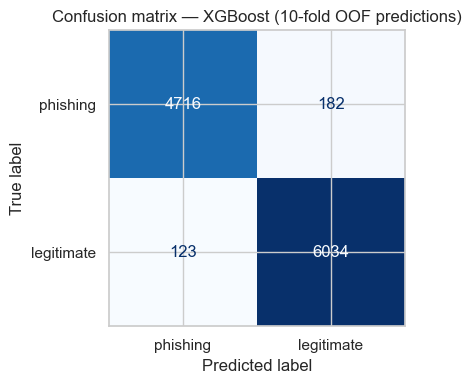

In [17]:
best_name = "XGBoost"
best_pipe, y_best = models[best_name][0], models[best_name][1]
y_pred = cross_val_predict(best_pipe, X, y_best, cv=cv, n_jobs=1)
cm = confusion_matrix(y_best, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["phishing", "legitimate"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Confusion matrix — {best_name} (10-fold OOF predictions)")
plt.tight_layout()
plt.show()


## 6. Error Analysis

In [18]:
y_pred_xgb = cross_val_predict(models["XGBoost"][0], X, y_bin, cv=cv, n_jobs=1)
fn_mask = (y_bin == 0) & (y_pred_xgb == 1)
fp_mask = (y_bin == 1) & (y_pred_xgb == 0)
print(f"False negatives (missed phishing): {fn_mask.sum()}")
print(f"False positives (legitimate flagged): {fp_mask.sum()}")

tp_mask = (y_bin == 0) & (y_pred_xgb == 0)
fn_means = X.loc[fn_mask].mean()
tp_means = X.loc[tp_mask].mean()
print("\nLargest |feature gap| between missed phishing (FN) and caught phishing (TP):")
print((fn_means - tp_means).abs().sort_values(ascending=False).head(6).round(3))


False negatives (missed phishing): 182
False positives (legitimate flagged): 123

Largest |feature gap| between missed phishing (FN) and caught phishing (TP):
SSLfinal_State        1.029
URL_of_Anchor         0.725
web_traffic           0.486
Request_URL           0.472
DNSRecord             0.352
Statistical_report    0.322
dtype: float64


**Cybersecurity trade-off:** False negatives let phishing pages reach users (credential theft).
False positives block or warn on benign sites (friction, alert fatigue). For deployment,
recall on phishing is often prioritized. The authors emphasize accuracy but do not discuss
this trade-off explicitly.